# Get stats for all tools in curated_tools.tsv, sum up the users for last 5 years. 


In [53]:
import matplotlib.pyplot as plt
import pandas as pd
import os


In [ ]:

COMMUNITY_PATH = "../../communities/imaging/"
CURATED_TOOLS_PATH = os.path.join(COMMUNITY_PATH, "resources", "curated_tools.tsv")
ALL_COMMUNITY_TOOLS_PATH = os.path.join(COMMUNITY_PATH, "metadata", "tool_status.tsv")
ALL_TOOLS = os.path.join("../../communities/all/", "resources", "tools.tsv")


# Load TSV file
all_tools = pd.read_csv(ALL_TOOLS, sep="\t")
c_tools = pd.read_csv(ALL_COMMUNITY_TOOLS_PATH, sep="\t")

# Filter rows where Suite ID matches
filtered_tools = all_tools[all_tools["Suite ID"].isin(c_tools["Suite ID"])]

In [ ]:
filtered_tools = filtered_tools.copy()

# Select the exact column
user_columns = ["Suite users (last 5 years) on main servers"]
#user_columns = ["Suite runs (last 5 years) on main servers"]

# Convert to numeric safely
filtered_tools[user_columns] = (
    filtered_tools[user_columns]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
)

# Sum total users
total_users = filtered_tools[user_columns].sum().sum()

print("Total users (last 5 years, main servers):", int(total_users))


Total users (last 5 years, main servers): 99399


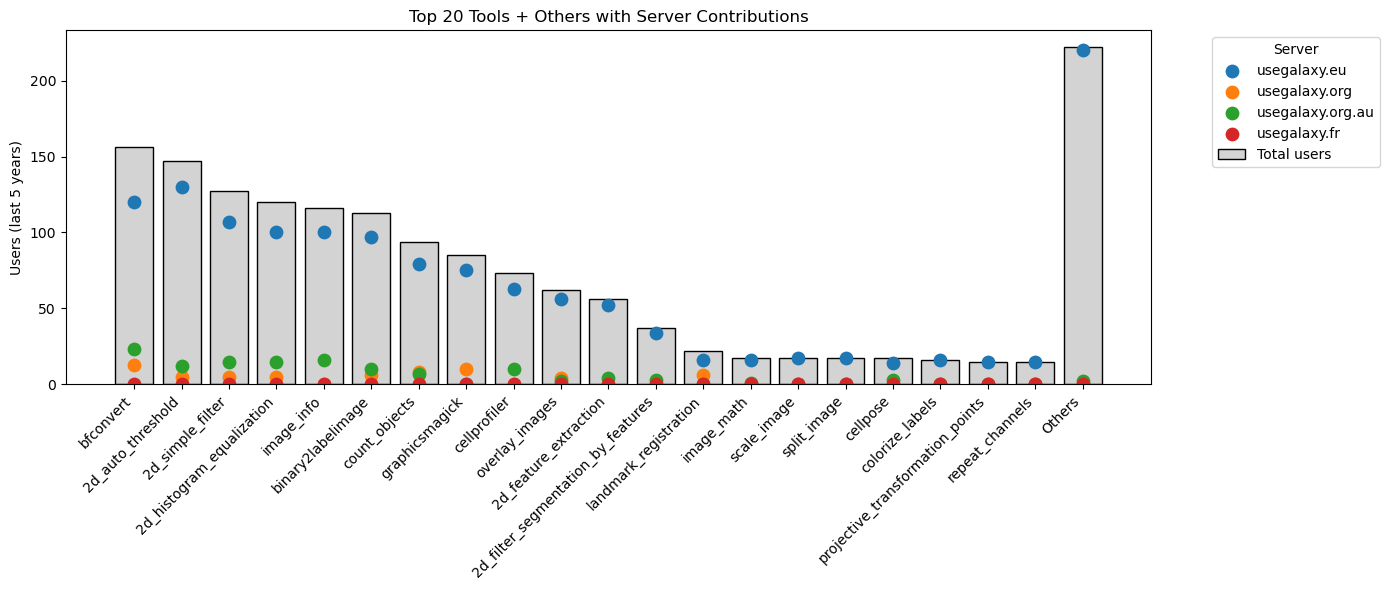

In [70]:
import matplotlib.pyplot as plt
import pandas as pd

# Assume filtered_tools is already loaded and cleaned

# Select all server columns for last 5 years (excluding main aggregate)
server_columns = [
    col for col in filtered_tools.columns
    if "Suite users (last 5 years)" in col
    and "main servers" not in col
]

# Ensure numeric
filtered_tools[server_columns] = filtered_tools[server_columns].apply(pd.to_numeric, errors="coerce").fillna(0)

# Clean server names for plotting
server_clean_names = [col.replace("Suite users (last 5 years) (", "").replace(")", "") for col in server_columns]

# Sum total users per tool
total_per_tool = filtered_tools[server_columns].sum(axis=1)

# Identify top 20 tools
top_n = 20
top_idx = total_per_tool.nlargest(top_n).index

# Split data
top_tools = filtered_tools.loc[top_idx].copy()
others = filtered_tools.drop(top_idx).copy()

# Combine the rest as "Others"
others_sum = others[server_columns].sum().to_frame().T
others_sum["Suite ID"] = "Others"
top_tools = pd.concat([top_tools, others_sum], ignore_index=True)

# Tool names
tools = top_tools["Suite ID"].astype(str)

# Total users per tool
total_users_per_tool = top_tools[server_columns].sum(axis=1)

# Plot
plt.figure(figsize=(14,6))

# Draw bars for total users
plt.bar(tools, total_users_per_tool, color="lightgray", edgecolor="black", label="Total users")

# Overlay dots for each server
colors = plt.cm.tab10.colors  # Up to 10 colors
for i, server in enumerate(server_columns):
    plt.scatter(
        tools,
        top_tools[server],
        color=colors[i % len(colors)],
        s=80,
        label=server_clean_names[i]
    )

plt.ylabel("Users (last 5 years)")
plt.title(f"Top {top_n} Tools + Others with Server Contributions")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Server", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


# Get IT users from the raw sql query

In [73]:
import pandas as pd
import os

BASE_PATH = "../../sources/data/usage_stats/usage_stats_2025.08.31"  # adjust if needed

servers = ["eu", "fr", "org", "org.au"]

interactive_tools = [
    "interactive_tool_anylabeling",
    "interactive_tool_bellavista",
    "interactive_tool_cellpose",
    "interactive_tool_cellprofiler",
    "interactive_tool_cellxgene",
    "interactive_tool_ilastik",
    "interactive_tool_napari",
    "interactive_tool_qupath",
]

all_data = []

for server in servers:
    file_path = os.path.join(
        BASE_PATH,
        server,
        "tool_users_5y_until_2025.08.31.csv"
    )
    
    df = pd.read_csv(file_path, header=None, names=["tool_id", "users"])

    # 🔹 Ensure numeric users
    df["users"] = pd.to_numeric(df["users"], errors="coerce").fillna(0)    

    # Extract last part after "/"
    df["tool_short"] = df["tool_id"].astype(str).str.split("/").str[-1]
    
    # Keep only interactive tools
    df_filtered = df[df["tool_short"].isin(interactive_tools)].copy()
    
    df_filtered["server"] = server

    all_data.append(df_filtered)

# Combine all servers
combined = pd.concat(all_data, ignore_index=True)
print(combined)

# # Total across all interactive tools
total_users = combined["users"].sum()
print("\nTotal users across all interactive tools (5y):", total_users)


                         tool_id  users                     tool_short  server
0     interactive_tool_cellxgene  244.0     interactive_tool_cellxgene      eu
1        interactive_tool_qupath   30.0        interactive_tool_qupath      eu
2      interactive_tool_cellpose   25.0      interactive_tool_cellpose      eu
3        interactive_tool_napari   18.0        interactive_tool_napari      eu
4  interactive_tool_cellprofiler   15.0  interactive_tool_cellprofiler      eu
5       interactive_tool_ilastik   12.0       interactive_tool_ilastik      eu
6   interactive_tool_anylabeling    8.0   interactive_tool_anylabeling      eu
7    interactive_tool_bellavista    2.0    interactive_tool_bellavista      eu
8     interactive_tool_cellxgene   28.0     interactive_tool_cellxgene  org.au

Total users across all interactive tools (5y): 382.0


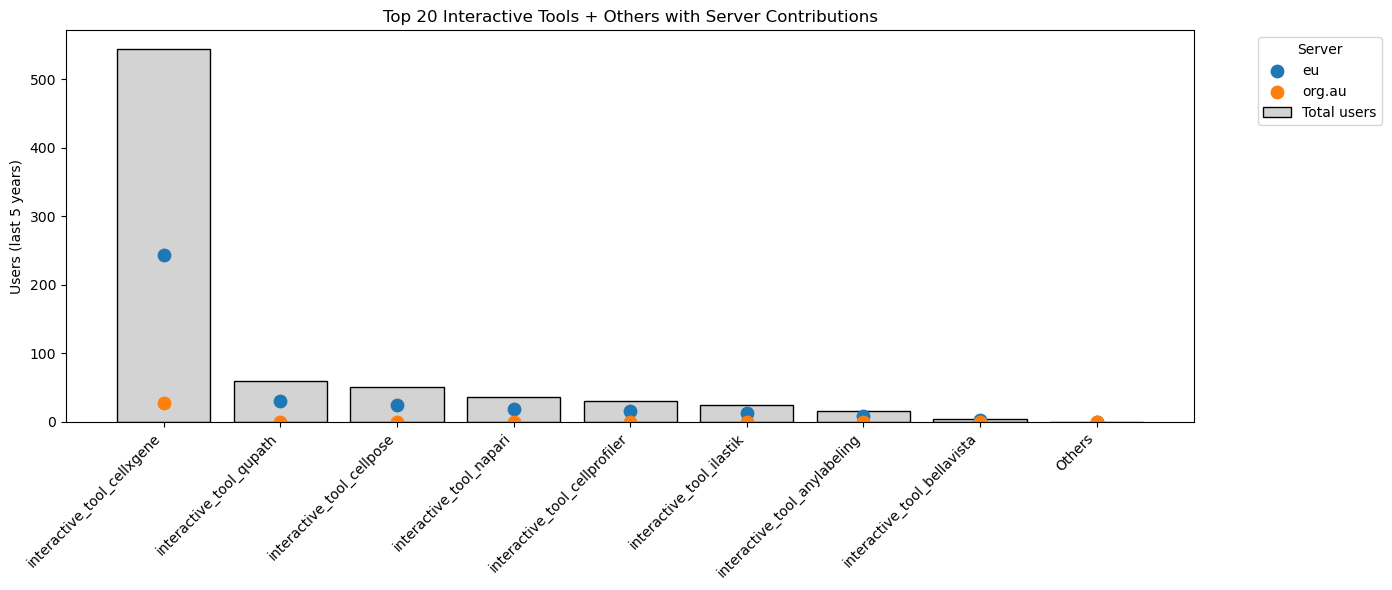

In [74]:

# Pivot to have one row per tool, columns = servers
plot_df = combined.pivot_table(
    index="tool_short",
    columns="server",
    values="users",
    aggfunc="sum",
    fill_value=0
)

# Compute total users per tool
plot_df["total_users"] = plot_df.sum(axis=1)

# -----------------------------
# Keep top 20 tools, combine rest as "Others"
# -----------------------------
top_n = 20
top_tools = plot_df.nlargest(top_n, "total_users")
others = plot_df.drop(top_tools.index)
others_sum = others.sum().to_frame().T
others_sum.index = ["Others"]

# Combine top tools + Others
plot_df = pd.concat([top_tools, others_sum])

# -----------------------------
# Plot
# -----------------------------
tools = plot_df.index.astype(str)
total_users_per_tool = plot_df.sum(axis=1)

plt.figure(figsize=(14,6))

# Draw bars for total users
plt.bar(tools, total_users_per_tool, color="lightgray", edgecolor="black", label="Total users")

# Overlay dots for each server
servers = combined["server"].unique()
colors = plt.cm.tab10.colors

for i, server in enumerate(servers):
    if server in plot_df.columns:
        plt.scatter(
            tools,
            plot_df[server],
            color=colors[i % len(colors)],
            s=80,
            label=server
        )

plt.ylabel("Users (last 5 years)")
plt.title(f"Top {top_n} Interactive Tools + Others with Server Contributions")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Server", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()